In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:0.4f}")

## Q1–2: Instrumental Variables

In [2]:
iv = pd.read_csv("homework_4.1.csv")
print(iv.shape)
iv.head()

(5000, 4)


,Z,W,X,Y
0,0,-0.1556,-0.4970,0.2825
1,1,0.5295,2.2842,4.7406
2,1,0.9105,0.8722,3.4496
3,1,-0.7055,2.1573,3.0025
4,0,-0.5909,-0.3867,-1.8488


In [3]:
iv.describe()

,Z,W,X,Y
count,5000.0000,5000.0000,5000.0000,5000.0000
mean,0.5014,-0.0099,0.5013,0.7403
std,0.5000,0.9978,1.1270,2.2257
min,0.0000,-3.3034,-3.4041,-7.0330
25%,0.0000,-0.6976,-0.2726,-0.7880
50%,1.0000,-0.0322,0.5169,0.7184
75%,1.0000,0.6476,1.2541,2.2407
max,1.0000,4.7833,4.6939,10.0820


In [4]:
naive_slope = np.polyfit(iv["X"], iv["Y"], 1)[0]
print(f"naive OLS slope: {naive_slope:.4f}")

naive OLS slope: 1.5110


In [5]:
y1, y0 = iv.loc[iv.Z==1, "Y"].mean(), iv.loc[iv.Z==0, "Y"].mean()
x1, x0 = iv.loc[iv.Z==1, "X"].mean(), iv.loc[iv.Z==0, "X"].mean()

dY, dX = y1 - y0, x1 - x0
wald = dY / dX

print(f"diff Y: {dY:.4f}  diff X: {dX:.4f}")
print(f"Wald estimate: {wald:.4f}")

diff Y: 1.5908  diff X: 1.0186
Wald estimate: 1.5619


In [6]:
iv2 = iv.copy()
iv2["Wbin"] = pd.qcut(iv2["W"], 20)

ratios = []
for _, g in iv2.groupby("Wbin", observed=True):
    g1, g0 = g[g.Z==1], g[g.Z==0]
    denom = g1["X"].mean() - g0["X"].mean()
    if len(g1) and len(g0) and denom != 0:
        ratios.append((g1["Y"].mean() - g0["Y"].mean()) / denom)

print(f"W-stratified IV: {np.mean(ratios):.4f}")
print(f"Wald:            {wald:.4f}")

W-stratified IV: 1.5055
Wald:            1.5619


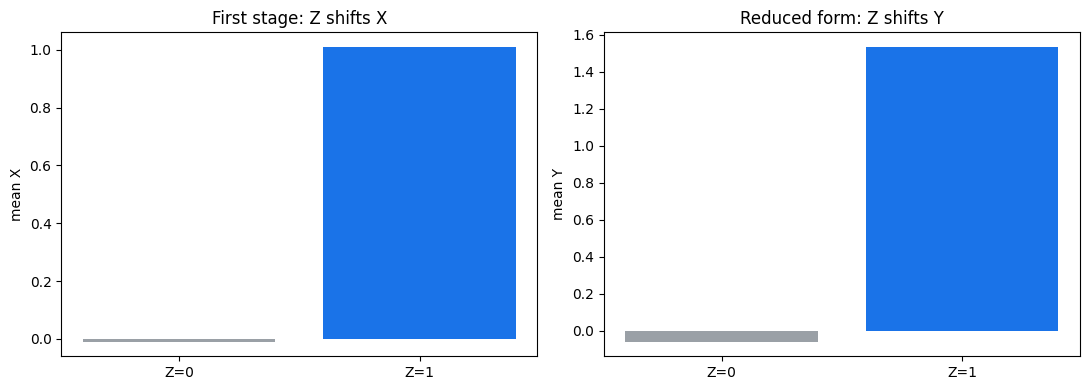

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].bar(["Z=0", "Z=1"], [x0, x1], color=["#9aa0a6", "#1a73e8"])
ax[0].set_title("First stage: Z shifts X"); ax[0].set_ylabel("mean X")

ax[1].bar(["Z=0", "Z=1"], [y0, y1], color=["#9aa0a6", "#1a73e8"])
ax[1].set_title("Reduced form: Z shifts Y"); ax[1].set_ylabel("mean Y")

plt.tight_layout(); plt.show()

## Q3–5: Regression Discontinuity (cutoff = 80)

In [8]:
CUT = 80

def load_rd(path):
    d = pd.read_csv(path)
    d.columns = ["X", "Y"]
    return d

a = load_rd("homework_4.2.a.csv")
b = load_rd("homework_4.2.b.csv")

def sides(d):
    below, above = d[d.X < CUT], d[d.X >= CUT]
    sb = np.polyfit(below.X, below.Y, 1)
    sa = np.polyfit(above.X, above.Y, 1)
    return sb, sa, below, above

for name, d in [("a", a), ("b", b)]:
    sb, sa, _, _ = sides(d)
    jump = np.polyval(sa, CUT) - np.polyval(sb, CUT)
    print(f"Dataset {name}: slope below={sb[0]:+.5f}  above={sa[0]:+.5f}  jump={jump:+.3f}")

Dataset a: slope below=+0.00022  above=+0.00016  jump=+0.296
Dataset b: slope below=+0.01022  above=+0.00501  jump=+0.197


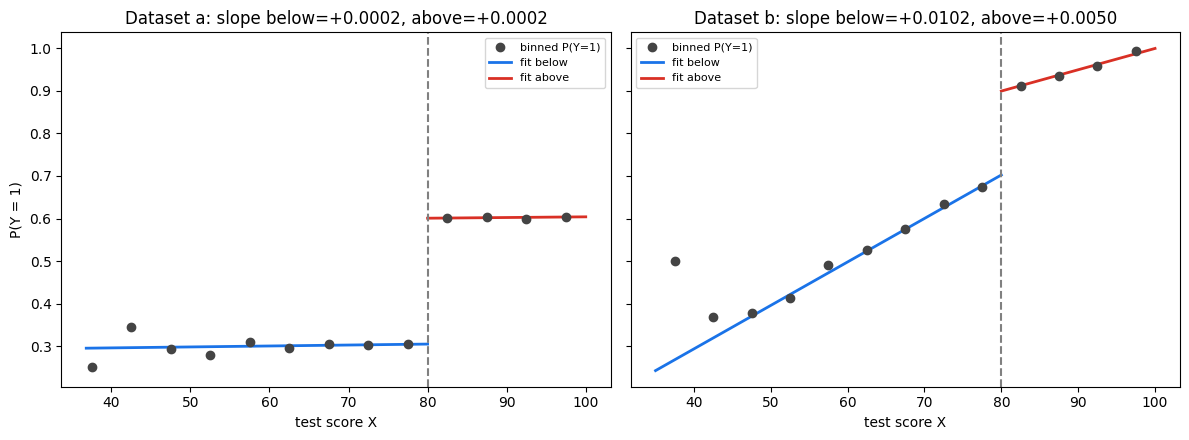

In [9]:
def binned(d, lo=35, hi=100, step=5):
    edges = np.arange(lo, hi + step, step)
    g = d.assign(bin=pd.cut(d.X, edges)).groupby("bin", observed=True).Y.mean()
    centers = [i.left + step/2 for i in g.index]
    return centers, g.values

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for axi, (name, d) in zip(ax, [("a", a), ("b", b)]):
    sb, sa, below, above = sides(d)
    cx, cy = binned(d)
    axi.scatter(cx, cy, color="#444", zorder=3, label="binned P(Y=1)")
    xb = np.linspace(d.X.min(), CUT, 50); xa = np.linspace(CUT, d.X.max(), 50)
    axi.plot(xb, np.polyval(sb, xb), color="#1a73e8", lw=2, label="fit below")
    axi.plot(xa, np.polyval(sa, xa), color="#d93025", lw=2, label="fit above")
    axi.axvline(CUT, ls="--", color="gray")
    axi.set_title(f"Dataset {name}: slope below={sb[0]:+.4f}, above={sa[0]:+.4f}")
    axi.set_xlabel("test score X"); axi.legend(fontsize=8)
ax[0].set_ylabel("P(Y = 1)")
plt.tight_layout(); plt.show()